<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/exoplanet_trappist1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exoplanet Discovery for TRAPPIST-1 (K2-112 or TIC 278892590)**

In [ ]:
!pip install lightkurve -q
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

[TRAPPIST-1](https://en.m.wikipedia.org/wiki/TRAPPIST-1) is a cool red dwarf star[c] with seven known exoplanets. It lies in constellation Aquarius 40.66 light-years away from Earth. TRAPPIST-1 is an ultracool M-dwarf star located 38.8 light-years away in the constellation of Aquarius. Also known as K2-112 or TIC 278892590

In [ ]:
# Choose exoplanet system with star
target = 'Trappist-1'
# target = 'Kepler-10'
#target = 'Kepler-8'
#target = 'HR8799'

**Pixel Visualization from raw TFP file**

In [ ]:
# Missions that inspected this exoplanet system
datalist = lk.search_targetpixelfile(target)
datalist

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 12,2016,K2,60,ktwo246199087,0.0
1,K2 Campaign 12,2016,K2,1800,ktwo246199087,0.0
2,K2 Campaign 19,2018,K2,60,ktwo246199087,0.0
3,K2 Campaign 19,2018,K2,1800,ktwo246199087,0.0
4,TESS Sector 70,2023,SPOC,20,278892590,0.0
5,TESS Sector 70,2023,SPOC,120,278892590,0.0
6,TESS Sector 70,2023,TESS-SPOC,200,278892590,0.0


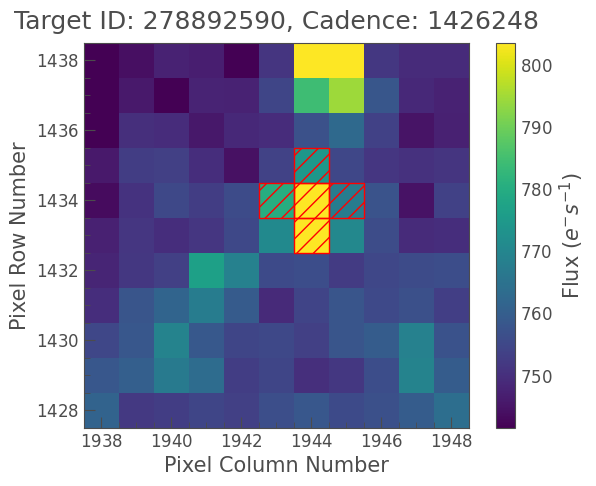

In [ ]:
# Get TESS data if available
tes = datalist[(datalist.author == "SPOC") & (datalist.exptime == 120*u.second)][0].download()
tes.plot(aperture_mask=tes.pipeline_mask)
fig = plt.gcf()
fig.set_size_inches(7, 5)
plt.show()

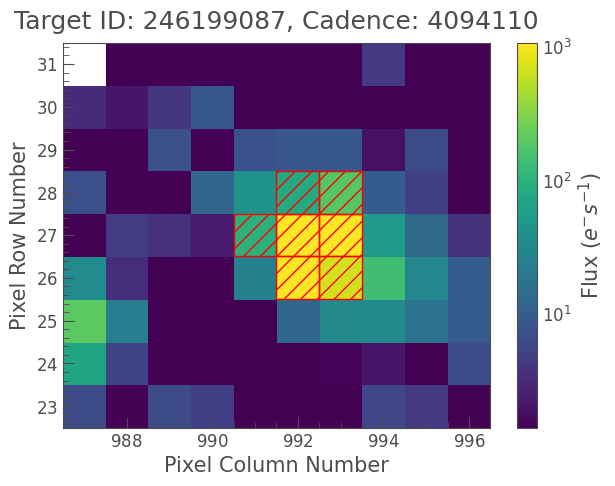

In [ ]:
# Get Kepler data if available
kep = datalist[(datalist.author == "K2") & (datalist.exptime == 60*u.second)][0].download() # or author Kepler etc
kep.plot(aperture_mask=kep.pipeline_mask, scale='log')
fig = plt.gcf()
fig.set_size_inches(7, 5)
plt.show()

In [ ]:
# Visualize how the target star's brightness evolves over time (Animate Exoplanet Movement)
pixelfile = lk.search_targetpixelfile(target)[1].download()
pixelfile

KeplerTargetPixelFile Object (ID: 246199087)

In [ ]:
pixelfile.animate()

**Transit fitting, period finding, and light curve analysis (from raw TPF data)**

pixelfile.to_lightcurve Convert pixel-level data into a light curve light curve (time series showing brightness of target star over time). This method returns a LightCurve object which details the flux and flux centroid position at each cadence

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

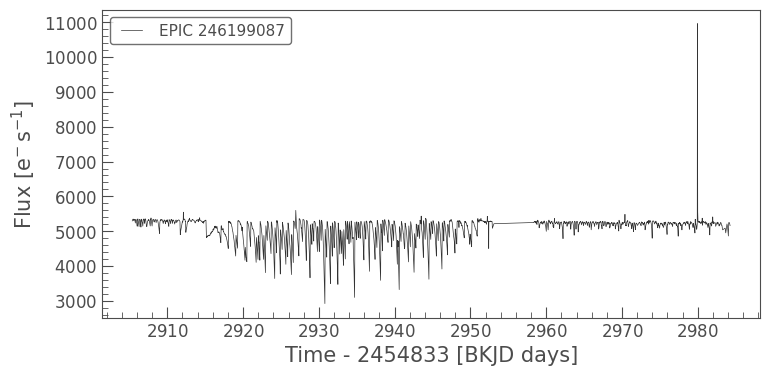

In [ ]:
# [Plot] Create Periodogram for Transit Detection from raw, original unprocessed data with noise
pixelfile.to_lightcurve().plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

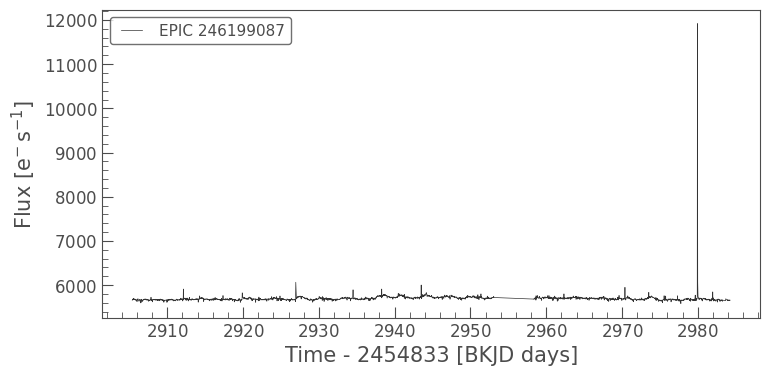

In [ ]:
# [Plot] Remove noise
pixelfile.to_lightcurve(method="pld").plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

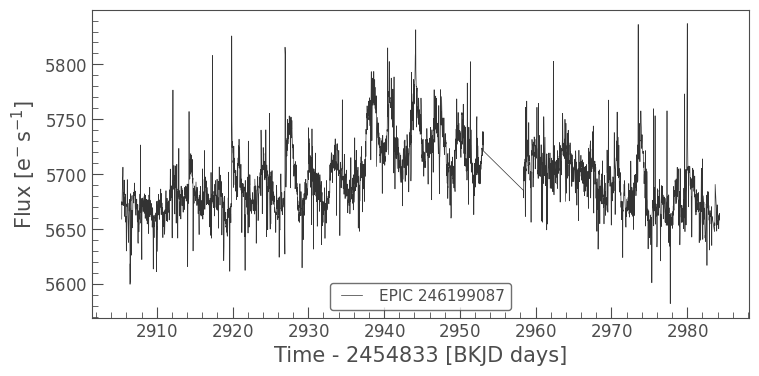

In [ ]:
# [Plot] Zoom in to flux movement (at y-axis) and remove outliers
pixelfile.to_lightcurve(method="pld").remove_outliers().plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

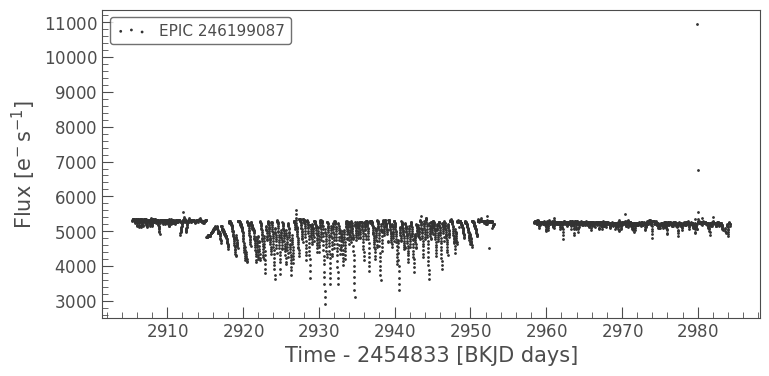

In [ ]:
# [Scatter] Create Periodogram for Transit Detection from raw, original unprocessed data with noise
pixelfile.to_lightcurve().scatter()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

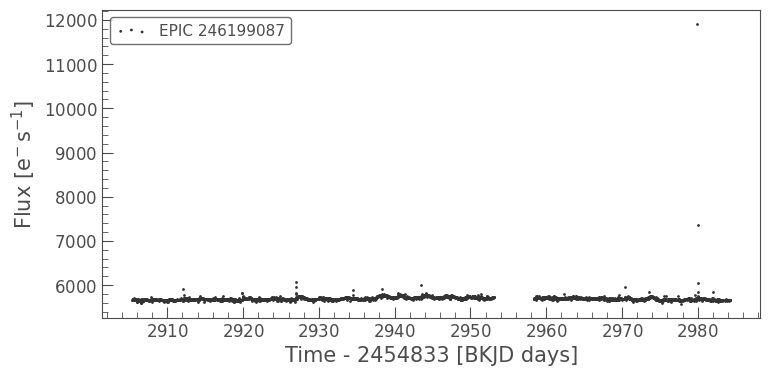

In [ ]:
# [Scatter] Remove noise, but leave outliers
pixelfile.to_lightcurve(method="pld").scatter()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

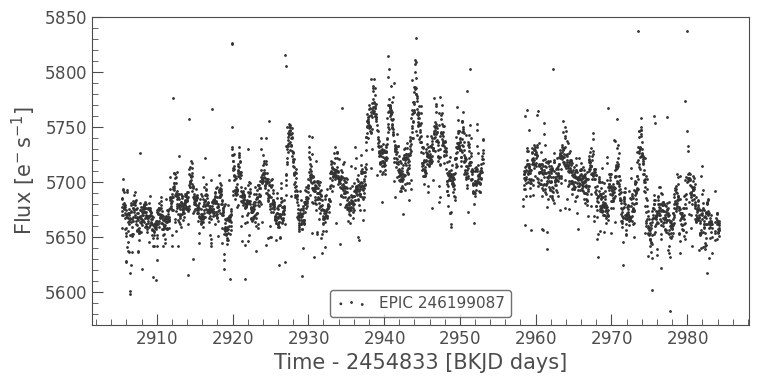

In [ ]:
# [Scatter] Zoom in to flux movement (at y-axis) and remove outliers
pixelfile.to_lightcurve(method="pld").remove_outliers().scatter()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

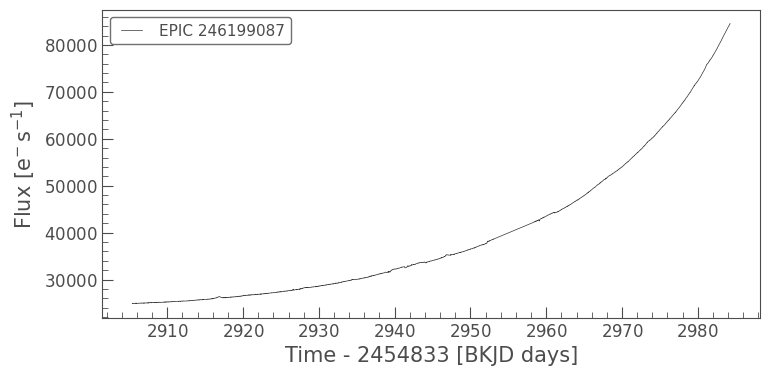

In [ ]:
# Plot background flux
pixelfile.get_bkg_lightcurve().plot()

<Axes: title={'center': 'Periodogram - Transit Detection'}, xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

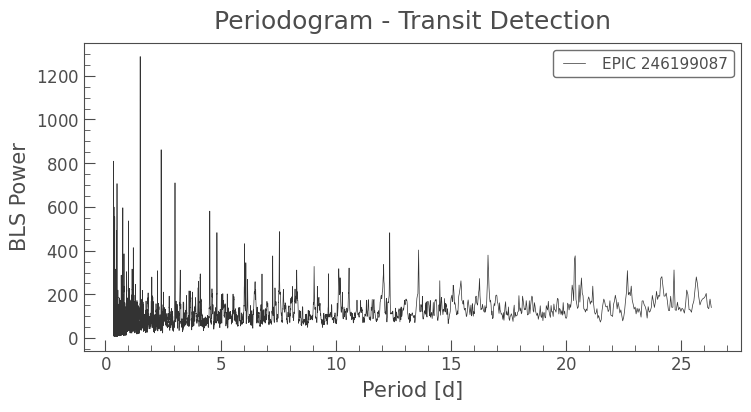

In [ ]:
# [Plot] Create Periodogram for Transit Detection, remove outliers and flatten, apply BLS
lc_pix = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten()
lc_pix.to_periodogram("bls").plot(title="Periodogram - Transit Detection")

<Quantity 1.51103729 d>

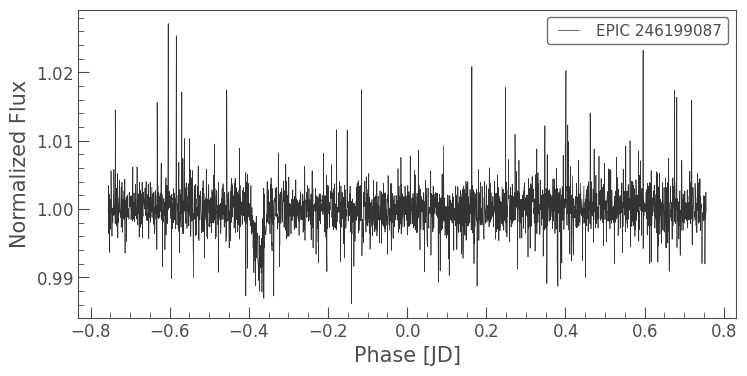

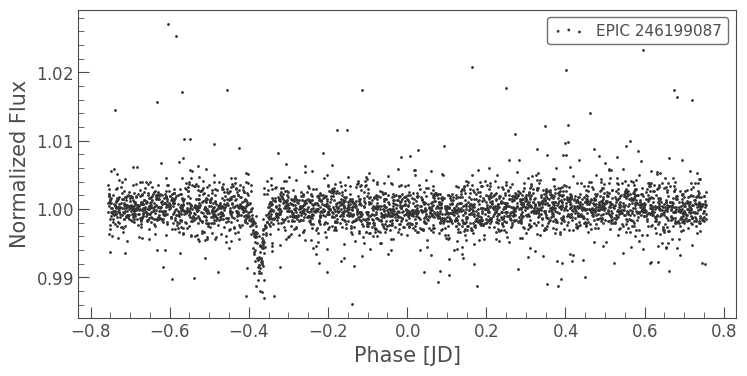

In [ ]:
# Period at max power
period = lc_pix.to_periodogram("bls").period_at_max_power
lc_pix.fold(period).plot()
lc_pix.fold(period).scatter()
period

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

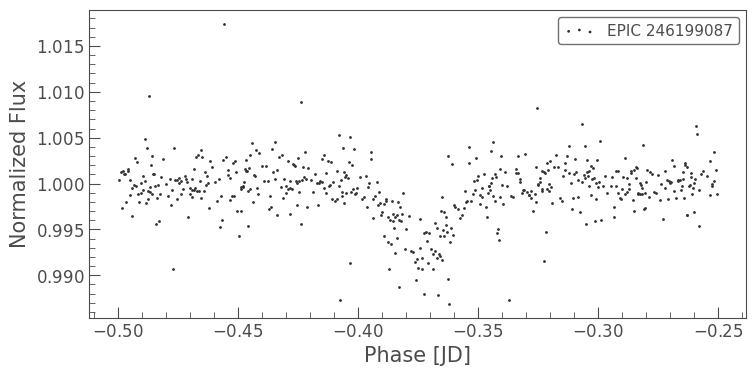

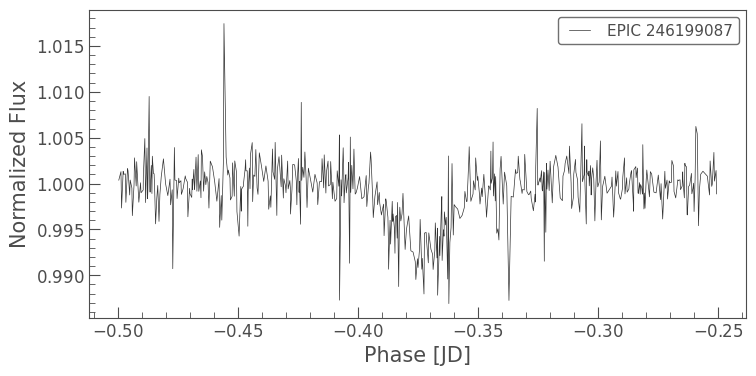

In [ ]:
# Focus on dip in lightcurve (at x-axis) as scatter and plot
lc_pix.fold(period).truncate(-0.5, -0.25).scatter()
lc_pix.fold(period).truncate(-0.5, -0.25).plot()

- **PLD (Pixel Level Decorrelation)**: Corrects for systematic noise at pixel level (noise from spacecraft motion in TESS or K2)
- **SAP (Simple Aperture Photometry)**: basic method that sums flux from an aperture of pixels, most prone to noise (for stable data)
- **PSF (Point Spread Function Fitting)**: Models star's light distribution, useful in crowded fields or extract light curves from overlapping PSFs
- **CBV (Cotrending Basis Vectors)**: Removes correlated noise by applying predefined corrections for known spacecraft systematics
- **SFF (Self-Flat-Fielding)**: Specialized for correcting K2 mission data by dealing with pixel sensitivity changes and pointing instabilities.

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

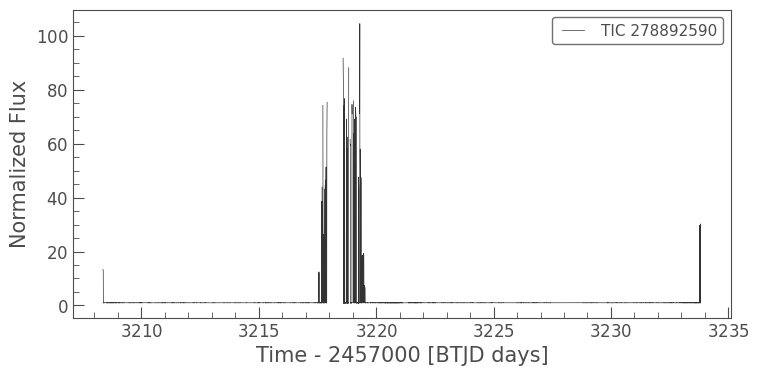

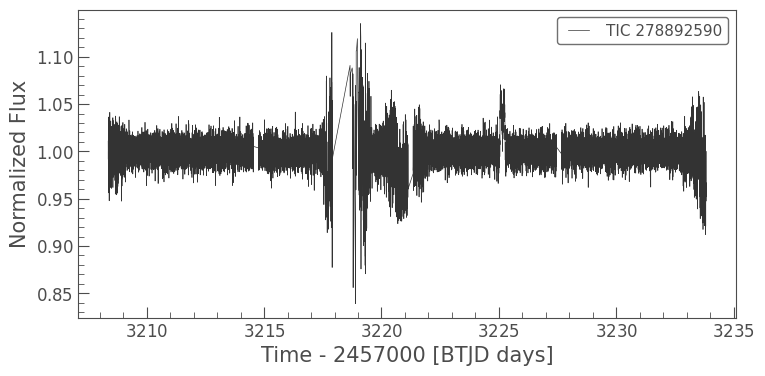

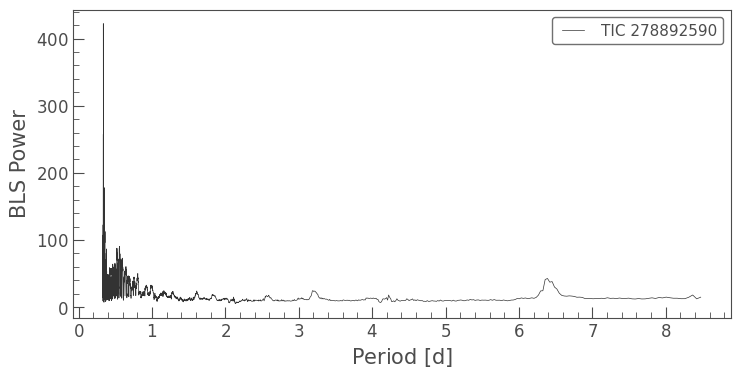

In [ ]:
# Load raw TESS data for to_lightcurve analysis - with outliers and not flattened
tes.to_lightcurve().flatten().plot(c='k', alpha=.8)
tes.to_lightcurve(method="pld").remove_outliers().flatten().plot(c='k', alpha=.8)
tes.to_lightcurve(method="pld").remove_outliers().flatten().to_periodogram("bls").plot()

<Quantity 0.33689913 d>

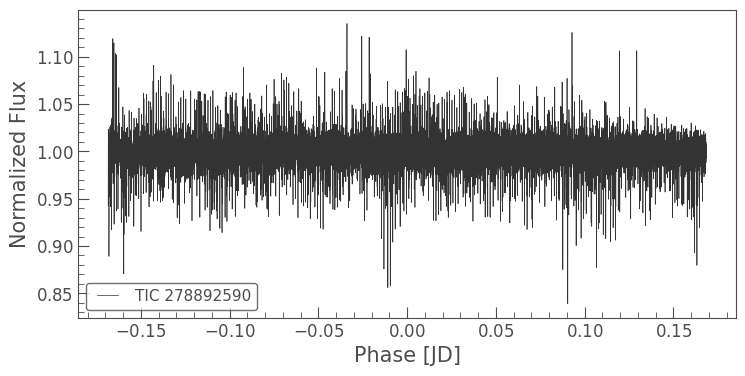

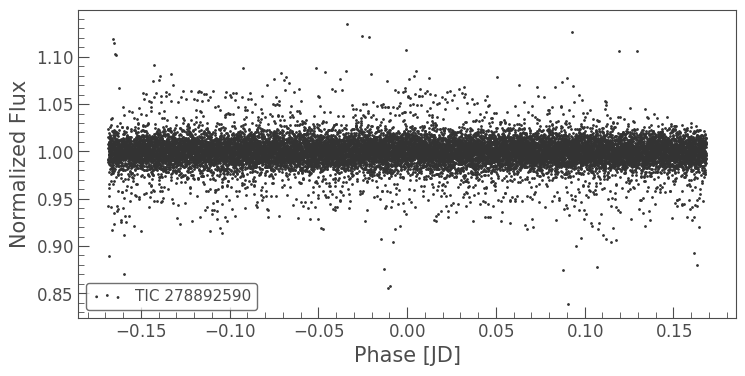

In [ ]:
# Define period - Remove outliers and flatten
lc_tes = tes.to_lightcurve(method="pld").remove_outliers().flatten()
period = lc_tes.to_periodogram("bls").period_at_max_power
lc_tes.fold(period).plot() #.truncate(-0.5, -0.25).plot()
lc_tes.fold(period).scatter() #truncate(-0.5, -0.25).scatter()
period

**Transit fitting, period finding, and light curve analysis (from preprocessed data)**

In [ ]:
# Choose mision and and download (light curve) data for target (Kepler ID or TIC ID)
# Load pre-processed light curves of TRAPPIST-1 observed by the TESS mission
# Useful for transit fitting, period finding, and light curve analysis without worrying about extracting flux from individual pixels

lc_search = lk.search_lightcurve(target, mission="TESS") # mission="Kepler"
print(lc_search)

SearchResult containing 3 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 70 2023      SPOC      20   278892590      0.0
  1 TESS Sector 70 2023      SPOC     120   278892590      0.0
  2 TESS Sector 70 2023 TESS-SPOC     200   278892590      0.0


/usr/local/lib/python3.10/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

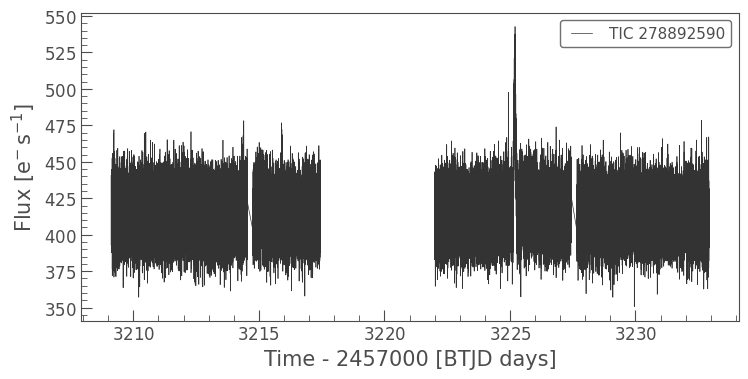

In [ ]:
# Download the data (just grabbing the first result here)
lc = lc_search.download(quality_bitmask="default")

# Plot the light curve
lc.plot(title=f"Light Curve for {target}")

<font color="blue">*Transit events of planets in the TRAPPIST-1 system in BJD or [Barycentric_Julian_Date](https://en.m.wikipedia.org/wiki/Barycentric_Julian_Date), specifically [TESS Barycentric Julian Day](https://heasarc.gsfc.nasa.gov/docs/tess/Target-Pixel-File-Tutorial.html) (BTJD). Sharp decrease in flux at regular intervals (transits) is a signature of planets orbiting the star. TRAPPIST-1 is known for having multiple planets, and the variations in depth and duration of these dips could correspond to different planetary transits.*
* <font color="blue">*The dips between 3217.5 and 3222 BTJD days (approximately 4.5 BTJD days) are multiple transit events. Each individual transit (dip in brightness) likely lasts a few hours or so.*
* <font color="blue">*If we measure the time between the start of one transit and the next, that time interval is the orbital period of the planet.*
* <font color="blue">*In case of TRAPPIST-1 system, several planets have relatively short orbital periods, so multiple transits can happen over just a few days.*


<Axes: title={'center': 'Periodogram - Transit Detection'}, xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

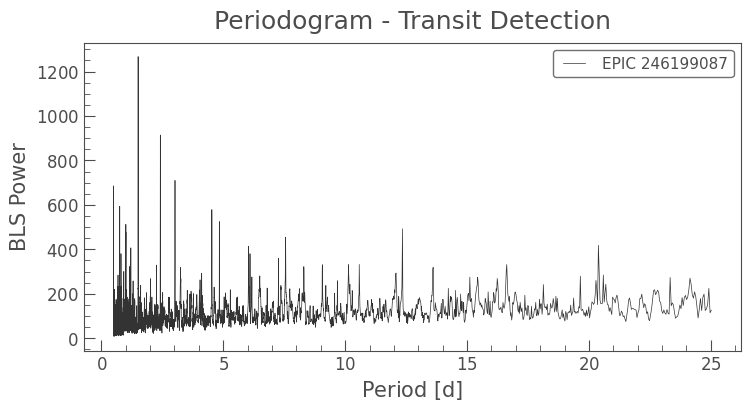

In [ ]:
# Clean the data by removing NaN values and flattening the curve
cleaned_lc = lc.remove_nans().flatten(window_length=401)

# Detect transits: Use a Box Least Squares (BLS) periodogram to find periodic dips in brightness, which could indicate planetary transits
periodogram = cleaned_lc.to_periodogram(method="bls", minimum_period=0.5, maximum_period=25)

# Plot the BLS periodogram to visualize detected periods (periodogram helps to visualize and extract the best-fit period, i.e. the time between transits
periodogram.plot(title="Periodogram - Transit Detection")

<Axes: title={'center': 'Periodogram - Transit Detection'}, xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

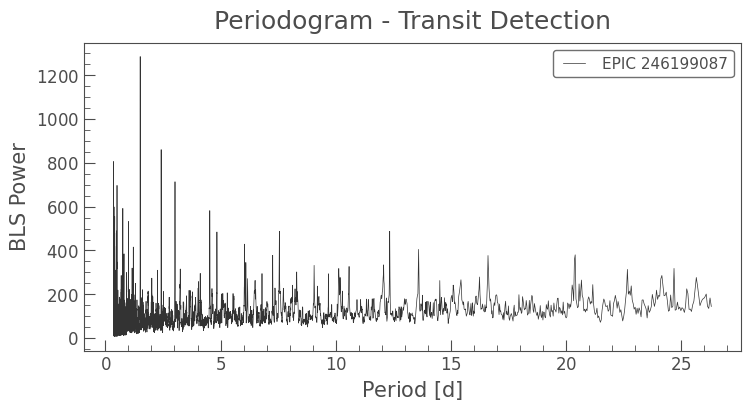

In [ ]:
# Compare with to periodogram from raw pixelfile data (vs above preprocessed LK data)
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten()
lc.to_periodogram("bls").plot(title="Periodogram - Transit Detection")

* <font color="blue">*This periodogram shows the strength of the signal (BLS power) as a function of the period in days. The BLS [Box Least Squares](https://docs.astropy.org/en/stable/timeseries/bls.html) algorithm is typically used for transit detection by identifying periodic dips in the light curve.*

* <font color="blue">*The prominent peak seen at a period of about 0.5 days suggests that there is a strong, repeating signal from a planet that has a very short orbital period—likely around half a day (12 hours).*

* <font color="blue">*This makes sense in the context of TRAPPIST-1, a system known for having multiple short-period planets. In this case, one of the planets may be orbiting the star very closely, resulting in frequent transits with an orbital period close to half a day.*

* <font color="blue">*The decreasing power for higher periods suggests that the shorter periods (likely closer-in planets) dominate the transit signature.*

* <font color="blue">*Beyond 5–10 days, the BLS power decreases significantly, suggesting there aren't strong periodic signals at longer periods. This means that if there are planets with longer orbital periods in this system, their transits are either weaker or not detected in this dataset.*

In [ ]:
# Get the best-fit transit period and duration
best_fit_period = periodogram.period_at_max_power
best_fit_duration = periodogram.duration_at_max_power
best_fit_depth = periodogram.depth_at_max_power

print(f"Best-fit period: {best_fit_period:.2f} days")
print(f"Best-fit transit duration: {best_fit_duration:.2f} days")
print(f"Transit depth: {best_fit_depth:.6f} relative flux")

Best-fit period: 0.51 d days
Best-fit transit duration: 0.33 d days
Transit depth: 0.001527 relative flux


* <font color="blue">*Best-fit period of 0.51 days suggests an ultra-short-period planet, orbiting TRAPPIST-1 in just over 12 hours.*
* <font color="blue">*Best-fit transit duration of 0.33 days implies that each transit lasts nearly 8 hours.*
* <font color="blue">*Transit depth of 0.001527 indicates that the planet blocks about 0.15% of the star's light during each transit, suggesting a planet that is not too large in size compared to the star.*

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

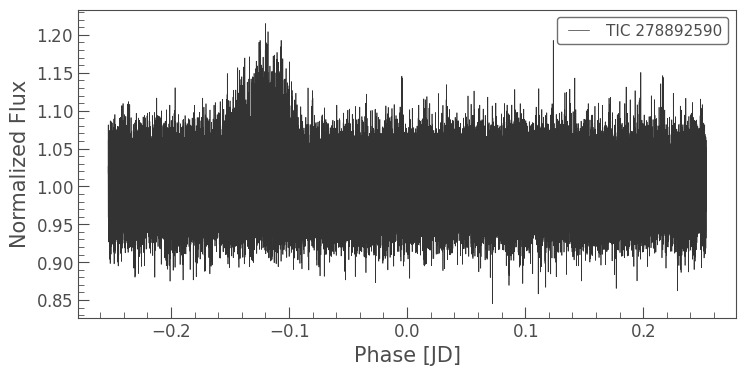

In [ ]:
# Generate "phase-folded light curve" by detected period to observe repeated transits more clearly
folded_lc = cleaned_lc.fold(period=best_fit_period.value)
folded_lc.plot(title=f"Folded Light Curve for {target} - Period: {best_fit_period:.2f} days")

*Phase folding is the process of taking the light curve data and "folding" it over a single period. By doing this, you overlay all the transit events on top of each other, allowing you to clearly see the recurring transit in one cycle. This is particularly useful for exoplanet studies because it helps remove noise and makes the periodic nature of the transits much more apparent.*

In [ ]:
# Estimate the planet radius (using transit depth and star's radius)
# Rp = planet radius, Rs = star radius, depth = fractional dip in brightness
star_radius = 1.065  # Solar radii for Kepler-10
planet_radius = star_radius * np.sqrt(best_fit_depth) # Formula: (Rp/Rs)^2 = depth
print(f"Estimated planet radius: {planet_radius:.2f} solar radii")

Estimated planet radius: 0.04 solar radii
